# 畳み込みニューラルネットワークと事前学習済みモデル

このノートブックでは，MLP では扱いにくい画像分類を題材にして，畳み込みニューラルネットワーク（CNN）と事前学習済みモデルの使い方を確認する。
学習ループは前章の後半と同じく Hugging Face Transformers の `Trainer` に任せる。

扱う流れは次の通りである。

1. CIFAR-100 の画像とラベルを確認する。
2. 小さな CNN を自分で定義し，5エポックだけ訓練する。
3. 訓練時間を測り，データセットが大きくなると学習時間がすぐ増えることを確認する。
4. MobileNetV3 の考え方を確認する。
5. ImageNet で事前学習済みの MobileNetV3 を読み込み，CIFAR-100 に転移する。
6. 最後の分類器だけを学習し，その後に全体をファインチューニングして精度の変化を確認する。


## 準備

初回実行時は CIFAR-100 と ImageNet pretrained MobileNetV3 の重みをダウンロードするため，インターネット接続が必要である。
`Trainer` は `labels` というキーを見つけると，モデルの `forward` に正解ラベルを渡す。
モデル側は `loss` と `logits` を含む辞書を返せばよい。


In [20]:
from __future__ import annotations

import random
import tempfile
import time
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import torch
import transformers
from PIL import Image
from jaxtyping import Float, Int64
from sklearn.metrics import accuracy_score, classification_report
from torch import nn
from torch.utils.data import Dataset, Subset
from torchvision import datasets, models, transforms
from torchvision.models import MobileNet_V3_Small_Weights
from transformers import Trainer, TrainingArguments
from transformers.trainer_utils import EvalPrediction

# 乱数の影響を抑えて，授業中に結果を比較しやすくする。
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU が使える場合は GPU，なければ CPU を使う。
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

# ノートブックをリポジトリ直下・book 内のどちらから実行しても同じデータ置き場を使う。
DATA_ROOT = Path("data") if Path("data").exists() else Path("../data")

print(f"device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")


device: mps
PyTorch: 2.11.0
Transformers: 5.8.1


## CIFAR-100 とは

CIFAR-100 は，32×32ピクセルのカラー画像を100クラスに分類するデータセットである。
訓練データは50,000枚，テストデータは10,000枚で，Iris dataset の150件と比べるとかなり大きい。

ただし，実用で使われる ImageNet などはさらに巨大である。
CIFAR-100 では5エポック程度なら試しやすいが，データ数や画像サイズが大きくなると，1エポックの時間も保存する重みのサイズも大きくなる。


In [21]:
# CIFAR-100 の画像は 32x32 ピクセルなので，まずは元の解像度で扱う。
image_size = 32
cifar100_mean = (0.5071, 0.4867, 0.4408)
cifar100_std = (0.2675, 0.2565, 0.2761)

# 学習用データには，左右反転とランダムクロップで簡単なデータ拡張を行う。
train_transform = transforms.Compose(
    [
        transforms.RandomCrop(image_size, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(cifar100_mean, cifar100_std),
    ]
)

# 評価用データにはランダム性を入れず，同じ前処理で評価できるようにする。
eval_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(cifar100_mean, cifar100_std),
    ]
)

# 初回だけ CIFAR-100 をダウンロードする。
cifar100_train_full = datasets.CIFAR100(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=train_transform,
)
cifar100_test = datasets.CIFAR100(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=eval_transform,
)

class_names = cifar100_train_full.classes
num_classes = len(class_names)

print("train size:", len(cifar100_train_full))
print("test size:", len(cifar100_test))
print("num classes:", num_classes)
print("first classes:", class_names[:10])


/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train size: 50000
test size: 10000
num classes: 100
first classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']


## 授業中に実行しやすいデータ量にする

CIFAR-100 全体を5エポック訓練すると，GPU では短時間で終わることが多いが，CPU ではかなり時間がかかることがある。
このノートでは，授業中に試しやすいように標準では訓練データの一部だけを使う。
全データで試したい場合は，`MAX_TRAIN_SAMPLES = None` と `MAX_EVAL_SAMPLES = None` に変更する。


In [22]:
# 授業中に実行しやすいよう，標準では一部のサンプルだけ使う。
MAX_TRAIN_SAMPLES: int | None = 10_000
MAX_EVAL_SAMPLES: int | None = 2_000

# 毎回同じサンプルを選ぶため，乱数生成器にもシードを指定する。
rng = np.random.default_rng(SEED)
train_indices = rng.permutation(len(cifar100_train_full))
eval_indices = rng.permutation(len(cifar100_test))

if MAX_TRAIN_SAMPLES is None:
    cifar100_train = cifar100_train_full
else:
    cifar100_train = Subset(cifar100_train_full, train_indices[:MAX_TRAIN_SAMPLES].tolist())

if MAX_EVAL_SAMPLES is None:
    cifar100_eval = cifar100_test
else:
    cifar100_eval = Subset(cifar100_test, eval_indices[:MAX_EVAL_SAMPLES].tolist())

print("train samples used:", len(cifar100_train))
print("eval samples used:", len(cifar100_eval))


train samples used: 10000
eval samples used: 2000


## 画像を確認する

正規化した Tensor はそのままだと色が見づらいので，表示時だけ平均と標準偏差を戻す。
画像分類では，入力の形が `3 × 32 × 32` であることも確認しておく。


image shape: (3, 32, 32)
label: 66 raccoon


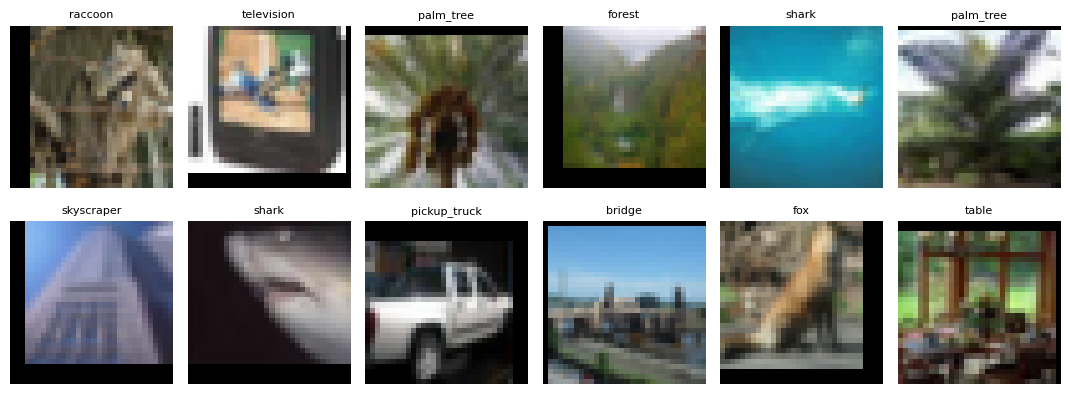

In [23]:
def denormalize_image(
    image: Float[torch.Tensor, "channel height width"],
    mean: tuple[float, float, float],
    std: tuple[float, float, float],
) -> Float[torch.Tensor, "channel height width"]:
    """正規化済み画像を表示用に戻す."""
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return (image.cpu() * std_t + mean_t).clamp(0, 1)


def show_examples(dataset: Dataset, rows: int = 2, cols: int = 6) -> None:
    """CIFAR-100 の画像例を表示する."""
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 2.1))
    for ax, index in zip(axes.ravel(), range(rows * cols), strict=False):
        image, label = dataset[index]
        image_to_show = denormalize_image(image, cifar100_mean, cifar100_std)
        ax.imshow(image_to_show.permute(1, 2, 0))
        ax.set_title(class_names[int(label)], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

sample_image, sample_label = cifar100_train[0]
print("image shape:", tuple(sample_image.shape))
print("label:", int(sample_label), class_names[int(sample_label)])
show_examples(cifar100_train)


### CIFAR 画像と特徴の見え方

次のデモでは，カラー画像に対する畳み込み・プーリングや，浅い層から深い層へ進むにつれて特徴が抽象化される様子を確認できる。

<p><a href="https://rsimd.github.io/NITIC-IntroductionToDeepLearning/cnn-color-convolution/" target="_blank" rel="noopener">別タブでカラー畳み込みデモを開く</a></p>

<iframe
  src="https://rsimd.github.io/NITIC-IntroductionToDeepLearning/cnn-color-convolution/?embed=1#nitic-embed-cnn-color-convolution"
  width="100%"
  height="760"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="カラー画像の畳み込みデモ"
></iframe>

<p><a href="https://rsimd.github.io/NITIC-IntroductionToDeepLearning/cnn-color-pooling/" target="_blank" rel="noopener">別タブでカラープーリングデモを開く</a></p>

<iframe
  src="https://rsimd.github.io/NITIC-IntroductionToDeepLearning/cnn-color-pooling/?embed=1#nitic-embed-cnn-color-pooling"
  width="100%"
  height="720"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="カラー画像のプーリングデモ"
></iframe>

<p><a href="https://rsimd.github.io/NITIC-IntroductionToDeepLearning/cnn-feature-hierarchy/" target="_blank" rel="noopener">別タブで特徴階層デモを開く</a></p>

<iframe
  src="https://rsimd.github.io/NITIC-IntroductionToDeepLearning/cnn-feature-hierarchy/?embed=1#nitic-embed-cnn-feature-hierarchy"
  width="100%"
  height="760"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="CNN 特徴階層デモ"
></iframe>


## `Trainer` に渡す Dataset とモデルラッパー

`torchvision.datasets.CIFAR100` は `(image, label)` のタプルを返す。
`Trainer` では辞書形式のほうが扱いやすいので，`features` と `labels` を返す小さなラッパーを用意する。

モデルも同様に，通常の PyTorch モデルを `loss` と `logits` を返す形に包む。


In [24]:
class ImageClassificationDataset(Dataset[dict[str, torch.Tensor]]):
    """画像とラベルを Trainer 用の辞書で返す Dataset."""

    def __init__(self, dataset: Dataset) -> None:
        self.dataset = dataset

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        image, label = self.dataset[index]
        return {
            "features": image,
            "labels": torch.tensor(label, dtype=torch.long),
        }


class ClassifierForTrainer(nn.Module):
    """Trainer で画像分類モデルを学習するためのラッパー."""

    def __init__(self, net: nn.Module, loss_fn: nn.Module) -> None:
        super().__init__()
        self.net = net
        self.loss_fn = loss_fn

    def forward(
        self,
        features: Float[torch.Tensor, "batch_size channel height width"],
        labels: Int64[torch.Tensor, "batch_size"] | None = None,
    ) -> dict[str, torch.Tensor]:
        logits = self.net(features)
        output = {"logits": logits}
        if labels is not None:
            output["loss"] = self.loss_fn(logits, labels)
        return output


trainer_train_dataset = ImageClassificationDataset(cifar100_train)
trainer_eval_dataset = ImageClassificationDataset(cifar100_eval)
trainer_test_dataset = ImageClassificationDataset(cifar100_test)


## 小さな CNN を定義する

CNN は，画像の近くの画素どうしの関係を使う。
`Conv2d` は小さなフィルタを画像全体へ滑らせながら特徴マップを作り，`MaxPool2d` は空間サイズを小さくする。
最後は `Linear` で100クラス分の `logits` を出す。


### CNN のアーキテクチャ図

![CIFAR-100 用 CNN のアーキテクチャ](../assets/cnn_architecture.svg)

畳み込み層では空間的に近い画素の関係を見て特徴マップを作る。
プーリングで解像度を下げながら重要な反応を残し，最後に分類器で100クラスへ変換する。


### CNN の動きをアニメーションで確認する

畳み込み・プーリング・特徴階層は，数式だけでなく動きとして見ると理解しやすい。
次のアニメーションでは，フィルタが画像上を移動しながら特徴マップを作る様子を確認できる。

<p><a href="https://rsimd.github.io/NITIC-IntroductionToDeepLearning/cnn-convolution/" target="_blank" rel="noopener">別タブで畳み込みアニメーションを開く</a></p>

<iframe
  src="https://rsimd.github.io/NITIC-IntroductionToDeepLearning/cnn-convolution/?embed=1#nitic-embed-cnn-convolution"
  width="100%"
  height="760"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="CNN 畳み込みアニメーション"
></iframe>

<p><a href="https://rsimd.github.io/NITIC-IntroductionToDeepLearning/cnn-pooling/" target="_blank" rel="noopener">別タブでプーリングアニメーションを開く</a></p>

<iframe
  src="https://rsimd.github.io/NITIC-IntroductionToDeepLearning/cnn-pooling/?embed=1#nitic-embed-cnn-pooling"
  width="100%"
  height="720"
  style="border: 1px solid #d7dde5; border-radius: 8px;"
  loading="lazy"
  title="CNN プーリングアニメーション"
></iframe>


In [25]:
def make_small_cnn(num_classes: int) -> nn.Sequential:
    """CIFAR-100 用の小さな CNN を作る."""
    return nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(128, num_classes),
    )


small_cnn = make_small_cnn(num_classes)
small_cnn_model = ClassifierForTrainer(small_cnn, nn.CrossEntropyLoss())
small_cnn_optimizer = torch.optim.AdamW(small_cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

small_cnn


Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): AdaptiveAvgPool2d(output_size=(1, 1))
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=128, out_features=100, bias=True)
)

### CNN の feature map の形状

このモデルでは `kernel_size=3, padding=1` の畳み込みを使っているので，畳み込みだけでは縦横サイズは変わらない。
縦横サイズを半分にしているのは `MaxPool2d(2)` である。

入力から出力までの主な形状は次の通りである。

- 入力：`batch_size × 3 × 32 × 32`
- Conv Block 1 後：`batch_size × 32 × 16 × 16`
- Conv Block 2 後：`batch_size × 64 × 8 × 8`
- Conv Block 3 後：`batch_size × 128 × 8 × 8`
- Global Average Pooling 後：`batch_size × 128 × 1 × 1`
- Flatten 後：`batch_size × 128`
- 分類器後：`batch_size × 100`


In [26]:
# 中間 feature map の形状を確認するため，1枚分のダミー画像を通す。
shape_check_model = make_small_cnn(num_classes)
shape_check_x = torch.zeros(1, 3, 32, 32)

print("input:", tuple(shape_check_x.shape))
current = shape_check_x
for layer_index, layer in enumerate(shape_check_model):
    current = layer(current)
    # 形状が変わる層だけ表示する。
    if isinstance(layer, (nn.Conv2d, nn.MaxPool2d, nn.AdaptiveAvgPool2d, nn.Flatten, nn.Linear)):
        print(f"{layer_index:02d} {layer.__class__.__name__}:", tuple(current.shape))


input: (1, 3, 32, 32)
00 Conv2d: (1, 32, 32, 32)
03 MaxPool2d: (1, 32, 16, 16)
04 Conv2d: (1, 64, 16, 16)
07 MaxPool2d: (1, 64, 8, 8)
08 Conv2d: (1, 128, 8, 8)
11 AdaptiveAvgPool2d: (1, 128, 1, 1)
12 Flatten: (1, 128)
13 Linear: (1, 100)


## CNN を `Trainer` で5エポック訓練する

ここでは5エポックだけ学習する。
CIFAR-100 は100クラス分類なので，最初から高精度を期待するよりも，損失と accuracy がどのように変化するかを見る。
同時に実行時間を測り，「データセットが大きくなると学習時間が効いてくる」ことを確認する。


In [27]:
def compute_accuracy(eval_pred: EvalPrediction) -> dict[str, float]:
    """Trainer の予測結果から accuracy を計算する."""
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    predictions = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}


def make_training_args(
    output_prefix: str,
    epochs: int,
    learning_rate: float,
    train_batch_size: int = 128,
    eval_batch_size: int = 256,
) -> TrainingArguments:
    """このノートで共通して使う TrainingArguments を作る."""
    return TrainingArguments(
        output_dir=tempfile.mkdtemp(prefix=output_prefix),
        num_train_epochs=epochs,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        learning_rate=learning_rate,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        report_to="none",
        remove_unused_columns=False,
        seed=SEED,
        use_cpu=DEVICE.type == "cpu",
    )


small_cnn_trainer = Trainer(
    model=small_cnn_model,
    args=make_training_args("cifar100-small-cnn-", epochs=5, learning_rate=1e-3),
    train_dataset=trainer_train_dataset,
    eval_dataset=trainer_eval_dataset,
    compute_metrics=compute_accuracy,
    optimizers=(small_cnn_optimizer, None),
)

start_time = time.perf_counter()
small_cnn_train_output = small_cnn_trainer.train()
small_cnn_elapsed = time.perf_counter() - start_time
small_cnn_metrics = small_cnn_trainer.evaluate(trainer_eval_dataset)

print(f"elapsed: {small_cnn_elapsed:.1f} sec")
small_cnn_metrics


/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,4.310390,4.141068,0.075000
2,3.991131,3.945556,0.102000
3,3.831052,3.830808,0.115000
4,3.746821,3.768606,0.128500
5,3.692166,3.728842,0.141000


/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on 

Training Loss,Validation Loss,Epoch,Accuracy
3.692166,3.728842,5,0.141000


elapsed: 14.9 sec


{'eval_loss': 3.728841781616211, 'eval_accuracy': 0.141}

## 学習ログを確認する

`Trainer` は各エポックの損失や評価結果を `state.log_history` に保存している。
訓練に時間がかかるときは，モデルだけでなく，データ数，画像サイズ，エポック数，バッチサイズの影響も確認する。


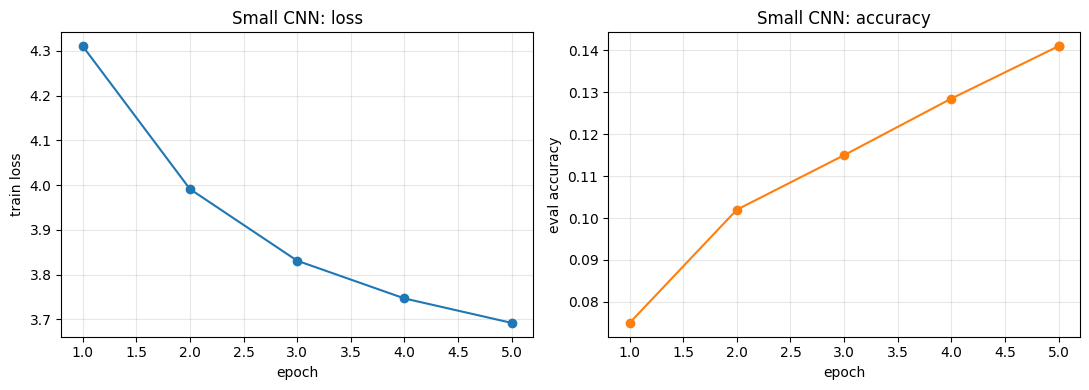

In [28]:
def plot_trainer_history(trainer: Trainer, title: str) -> None:
    """Trainer のログから loss と eval accuracy を描画する."""
    log_history = trainer.state.log_history
    train_epochs = [item["epoch"] for item in log_history if "loss" in item]
    train_losses = [item["loss"] for item in log_history if "loss" in item]
    eval_epochs = [item["epoch"] for item in log_history if "eval_accuracy" in item]
    eval_accuracies = [item["eval_accuracy"] for item in log_history if "eval_accuracy" in item]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(train_epochs, train_losses, marker="o")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("train loss")
    axes[0].set_title(f"{title}: loss")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(eval_epochs, eval_accuracies, marker="o", color="tab:orange")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("eval accuracy")
    axes[1].set_title(f"{title}: accuracy")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_trainer_history(small_cnn_trainer, "Small CNN")


In [29]:
images_per_epoch = len(trainer_train_dataset)
seconds_per_epoch = small_cnn_elapsed / 5
seconds_per_image = small_cnn_elapsed / (images_per_epoch * 5)

print(f"1 epoch: {images_per_epoch:,} images")
print(f"seconds / epoch: {seconds_per_epoch:.1f}")
print(f"seconds / image: {seconds_per_image:.6f}")
print(f"estimated 50,000 images x 5 epochs: {seconds_per_image * 50_000 * 5 / 60:.1f} min")
print(f"estimated 1,000,000 images x 5 epochs: {seconds_per_image * 1_000_000 * 5 / 3600:.1f} hours")

1 epoch: 10,000 images
seconds / epoch: 3.0
seconds / image: 0.000297
estimated 50,000 images x 5 epochs: 1.2 min
estimated 1,000,000 images x 5 epochs: 0.4 hours


## MobileNetV3 の考え方

MobileNetV3 は，スマートフォンや組み込み機器のような計算資源が限られた環境でも使いやすいように設計された CNN である。
通常の畳み込みをそのまま重ねるのではなく，計算量を減らすための工夫を組み合わせている。

主なポイントは次の通りである。

- **Depthwise separable convolution**：チャンネルごとの畳み込みと，チャンネルを混ぜる1×1畳み込みに分けて計算量を減らす。
- **Inverted residual block**：いったんチャンネル数を広げて特徴を作り，最後に小さく戻す。
- **Squeeze-and-Excitation**：画像全体の情報から，どのチャンネルを強く使うかを調整する。
- **h-swish / h-sigmoid**：精度と計算効率のバランスを取った活性化関数を使う。
- **Neural Architecture Search**：人手だけでなく探索によって，速度と精度のバランスがよい構造を選んでいる。

ここでは `MobileNet_V3_Small` を使う。
ImageNet で事前学習済みの重みを読み込み，最後の分類層だけ CIFAR-100 の100クラスに置き換える。


### MobileNetV3 のアーキテクチャ図

![MobileNetV3 による転移学習のアーキテクチャ](../assets/mobilenetv3_architecture.svg)

このノートでは，まず `features` を固定して分類器だけを学習し，その後に全体を小さい学習率でファインチューニングする。

## ImageNet pretrained MobileNetV3 を読み込む

ImageNet 事前学習済みモデルは，1000クラスの自然画像で学習されている。
CIFAR-100 のクラスとは完全には一致しないが，エッジや色，形のような低レベル特徴は再利用できる。

MobileNetV3 では，入力画像を224×224へリサイズし，ImageNet の平均と標準偏差で正規化する。まず特徴抽出器を固定し，最後の分類器だけを学習する。
この段階では，ImageNet で得た特徴を CIFAR-100 の100クラスへ対応させる分類器を作っていると考える。


## ImageNet 形式の画像を確認する

ImageNet 本体の画像は利用許諾が必要なので，ここでは同じような自然画像を公開サンプルから読み込み，MobileNetV3 用の前処理で確認する。
実際の ImageNet pretrained モデルは，このような224×224の自然画像を大量に見て学習している。


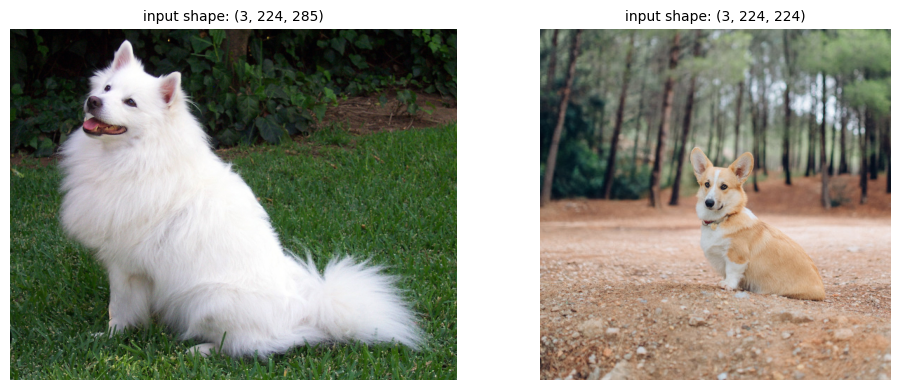

In [30]:
imagenet_example_urls = [
    # PyTorch 公式サンプル画像。犬は ImageNet の代表的な分類対象である。
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
    # 複数物体が写る自然画像。ImageNet pretrained モデルの入力形式を確認するために使う。
    "https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/dog1.jpg",
]


def show_imagenet_style_examples(urls: list[str]) -> None:
    """公開サンプル画像を読み込み，MobileNetV3 用の入力例として表示する."""
    fig, axes = plt.subplots(1, len(urls), figsize=(5 * len(urls), 4))
    if len(urls) == 1:
        axes = [axes]

    for ax, url in zip(axes, urls, strict=False):
        # URL から画像を読み込み，PIL Image として RGB にそろえる。
        image = Image.open(urlopen(url)).convert("RGB")
        # MobileNetV3 の評価時と同じ前処理を適用し，入力テンソルの形を確認する。
        tensor = mobilenet_eval_transform(image)

        ax.imshow(image)
        ax.set_title(f"input shape: {tuple(tensor.shape)}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_imagenet_style_examples(imagenet_example_urls)


In [31]:
# ImageNet pretrained モデルで標準的に使われる平均と標準偏差。
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

# MobileNetV3 は ImageNet で 224x224 入力として学習されているので，CIFAR 画像を拡大する。
mobilenet_train_transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

mobilenet_eval_transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

# 同じ CIFAR-100 でも，MobileNetV3 用には前処理を変えた Dataset を作る。
mobilenet_train_full = datasets.CIFAR100(
    root=DATA_ROOT,
    train=True,
    download=False,
    transform=mobilenet_train_transform,
)
mobilenet_test_full = datasets.CIFAR100(
    root=DATA_ROOT,
    train=False,
    download=False,
    transform=mobilenet_eval_transform,
)

if MAX_TRAIN_SAMPLES is None:
    mobilenet_train = mobilenet_train_full
else:
    mobilenet_train = Subset(mobilenet_train_full, train_indices[:MAX_TRAIN_SAMPLES].tolist())

if MAX_EVAL_SAMPLES is None:
    mobilenet_eval = mobilenet_test_full
else:
    mobilenet_eval = Subset(mobilenet_test_full, eval_indices[:MAX_EVAL_SAMPLES].tolist())

mobilenet_train_dataset = ImageClassificationDataset(mobilenet_train)
mobilenet_eval_dataset = ImageClassificationDataset(mobilenet_eval)
mobilenet_test_dataset = ImageClassificationDataset(mobilenet_test_full)

mobilenet_sample, _ = mobilenet_train[0]
print("MobileNetV3 input shape:", tuple(mobilenet_sample.shape))


/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


MobileNetV3 input shape: (3, 224, 224)


In [32]:
def replace_mobilenet_classifier(model: nn.Module, num_classes: int) -> nn.Module:
    """MobileNetV3 の最後の分類層を CIFAR-100 用に置き換える."""
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model


def set_trainable(module: nn.Module, trainable: bool) -> None:
    """モジュール内のパラメータを学習対象にするかを切り替える."""
    for parameter in module.parameters():
        parameter.requires_grad = trainable


# TorchVision が提供する ImageNet pretrained の MobileNetV3-Small を使う。
mobilenet_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet_feature_extractor = models.mobilenet_v3_small(weights=mobilenet_weights)
mobilenet_feature_extractor = replace_mobilenet_classifier(mobilenet_feature_extractor, num_classes)

# 最初は特徴抽出器を固定し，新しく付け替えた分類器だけを学習する。
set_trainable(mobilenet_feature_extractor.features, False)
set_trainable(mobilenet_feature_extractor.classifier, True)

feature_model = ClassifierForTrainer(mobilenet_feature_extractor, nn.CrossEntropyLoss())
display(feature_model)

feature_optimizer = torch.optim.AdamW(
    (parameter for parameter in feature_model.parameters() if parameter.requires_grad),
    lr=1e-3,
    weight_decay=1e-4,
)

trainable_params = sum(parameter.numel() for parameter in feature_model.parameters() if parameter.requires_grad)
total_params = sum(parameter.numel() for parameter in feature_model.parameters())
print(f"trainable params: {trainable_params:,} / {total_params:,}")


ClassifierForTrainer(
  (net): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2):

trainable params: 693,348 / 1,620,356


## 分類器だけを訓練して評価する

ImageNet pretrained の特徴抽出器を固定すると，更新するパラメータが少ないため比較的速く学習できる。
学習前後の accuracy を見て，ランダムに初期化された分類器がどの程度 CIFAR-100 に適応したかを確認する。


In [37]:
feature_trainer = Trainer(
    model=feature_model,
    args=make_training_args("cifar100-mobilenet-feature-", epochs=5, learning_rate=1e-3, train_batch_size=2000, eval_batch_size=2000),
    train_dataset=mobilenet_train_dataset,
    eval_dataset=mobilenet_eval_dataset,
    compute_metrics=compute_accuracy,
    optimizers=(feature_optimizer, None),
)

feature_before_metrics = feature_trainer.evaluate(mobilenet_eval_dataset)
start_time = time.perf_counter()
feature_train_output = feature_trainer.train()
feature_elapsed = time.perf_counter() - start_time
feature_after_metrics = feature_trainer.evaluate(mobilenet_eval_dataset)

print(f"elapsed: {feature_elapsed:.1f} sec")
print("before:", feature_before_metrics)
print("after:", feature_after_metrics)

Training Loss,Validation Loss,Epoch,Accuracy
No log,2.037840,0,0.454000


/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.857405,2.014395,0.463500
2,0.846211,1.998434,0.468000
3,0.845689,1.985050,0.469500
4,0.847420,1.962468,0.479000
5,0.833094,1.947898,0.477500


/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on 

Training Loss,Validation Loss,Epoch,Accuracy
0.833094,1.947898,5,0.477500


elapsed: 56.9 sec
before: {'eval_loss': 2.0378401279449463, 'eval_accuracy': 0.454}
after: {'eval_loss': 1.9478983879089355, 'eval_accuracy': 0.4775}


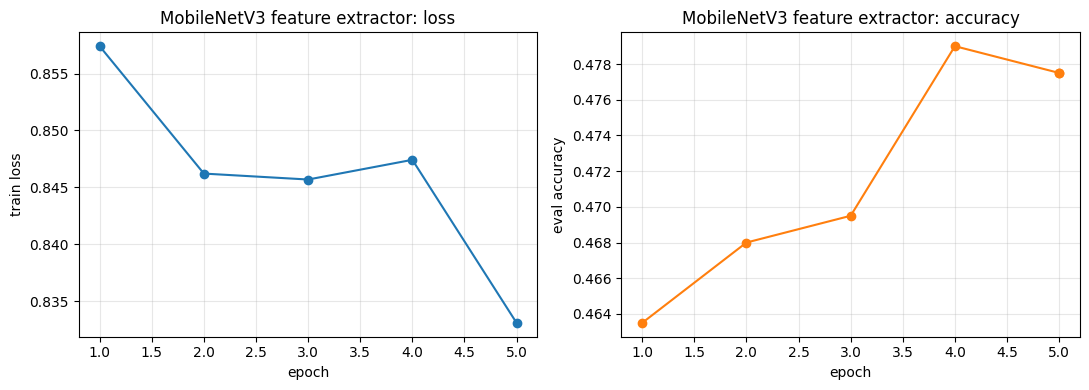

In [38]:
plot_trainer_history(feature_trainer, "MobileNetV3 feature extractor")


## ファインチューニングする

分類器だけの学習では，ImageNet で学習した特徴抽出器は固定されたままである。
次に全体のパラメータを学習対象に戻し，小さい学習率で追加訓練する。
これをファインチューニングと呼ぶ。

学習率を小さくするのは，事前学習で得た有用な特徴を大きく壊さないようにするためである。


In [39]:
set_trainable(mobilenet_feature_extractor, True)

fine_tune_optimizer = torch.optim.AdamW(
    feature_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

fine_tune_trainer = Trainer(
    model=feature_model,
    args=make_training_args("cifar100-mobilenet-finetune-", epochs=3, learning_rate=1e-4, train_batch_size=2000, eval_batch_size=2000),
    train_dataset=mobilenet_train_dataset,
    eval_dataset=mobilenet_eval_dataset,
    compute_metrics=compute_accuracy,
    optimizers=(fine_tune_optimizer, None),
)

fine_tune_before_metrics = fine_tune_trainer.evaluate(mobilenet_eval_dataset)
start_time = time.perf_counter()
fine_tune_output = fine_tune_trainer.train()
fine_tune_elapsed = time.perf_counter() - start_time
fine_tune_after_metrics = fine_tune_trainer.evaluate(mobilenet_eval_dataset)

print(f"elapsed: {fine_tune_elapsed:.1f} sec")
print("before fine-tuning:", fine_tune_before_metrics)
print("after fine-tuning:", fine_tune_after_metrics)

/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
No log,1.947898,0,0.477500


/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.720453,1.698803,0.536500
2,0.679594,1.621256,0.552500
3,0.671281,1.596508,0.556000


/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
0.671281,1.596508,3,0.556000


elapsed: 57.1 sec
before fine-tuning: {'eval_loss': 1.9478983879089355, 'eval_accuracy': 0.4775}
after fine-tuning: {'eval_loss': 1.5965081453323364, 'eval_accuracy': 0.556}


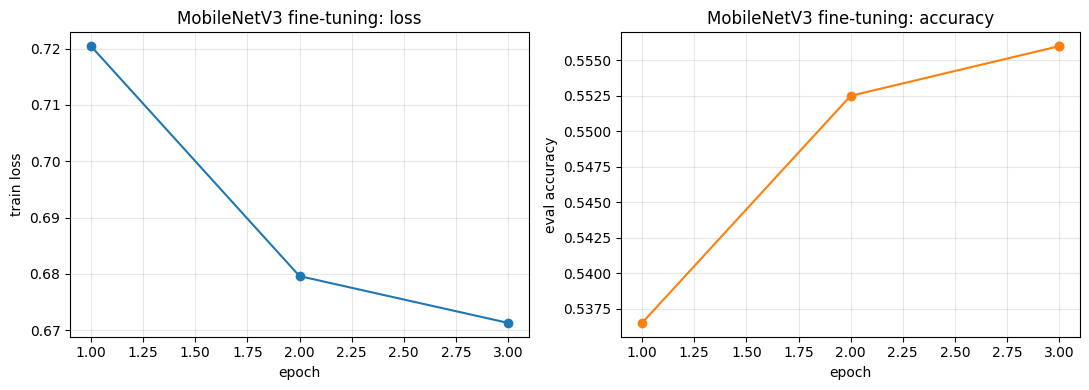

In [40]:
plot_trainer_history(fine_tune_trainer, "MobileNetV3 fine-tuning")


## テストデータで最終確認する

最後に，学習中に使っていないテストデータで accuracy を確認する。
授業中に一部データで実行した場合，数値は実行環境やサンプル数によって変わる。
重要なのは，事前学習済み特徴の利用とファインチューニングによって，ゼロから小さな CNN を学習する場合とは違う出発点を使えることである。


In [41]:
final_test_metrics = fine_tune_trainer.evaluate(mobilenet_test_dataset)
final_test_metrics


/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
0.671281,1.613705,3,0.557800


{'eval_loss': 1.6137045621871948, 'eval_accuracy': 0.5578}

In [42]:
prediction_output = fine_tune_trainer.predict(mobilenet_test_dataset)
y_pred = np.argmax(prediction_output.predictions, axis=1)
y_true = prediction_output.label_ids

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


/Users/mriki/MyBooks/NITIC-IntroductionToDeepLearning/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


               precision    recall  f1-score   support

        apple       0.76      0.82      0.79       100
aquarium_fish       0.75      0.44      0.55       100
         baby       0.62      0.42      0.50       100
         bear       0.64      0.29      0.40       100
       beaver       0.35      0.33      0.34       100
          bed       0.57      0.59      0.58       100
          bee       0.59      0.66      0.63       100
       beetle       0.62      0.62      0.62       100
      bicycle       0.91      0.72      0.80       100
       bottle       0.86      0.68      0.76       100
         bowl       0.60      0.41      0.49       100
          boy       0.37      0.39      0.38       100
       bridge       0.53      0.52      0.52       100
          bus       0.43      0.52      0.47       100
    butterfly       0.55      0.59      0.57       100
        camel       0.67      0.64      0.66       100
          can       0.77      0.68      0.72       100
       ca

## まとめ

このノートブックでは，画像分類を通して次の点を確認した。

- 画像は表形式データと違い，近くの画素どうしの関係が重要である。
- CNN は畳み込みによって局所的なパターンを取り出し，分類に使える特徴へ変換する。
- `Trainer` を使うと，PyTorch の独自モデルでも定型的な学習ループを任せられる。
- データ数，画像サイズ，エポック数が増えると，学習時間はすぐ大きくなる。
- MobileNetV3 は軽量な画像分類モデルであり，ImageNet pretrained の特徴を転移学習に利用できる。
- 分類器だけの学習よりも，全体を小さい学習率でファインチューニングすると精度が上がる場合が多い。
